### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as  sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid", palette="muted")

import os
os.makedirs('../outputs/charts', exist_ok=True)
print(" Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

 Libraries loaded successfully!
Pandas version: 2.3.3
NumPy version:  2.2.6


### Load Datasets and Document Basic Info

In [20]:
historical_data = pd.read_csv(r"D:\Internship\data\historical_data.csv")
fear_greed = pd.read_csv(r"D:\Internship\data\fear_greed_index.csv")

In [21]:
print("Bitcoin Market sentiment (Fear/Greed)")
print(f"Shape       : {fear_greed.shape[0]:,} rows × {fear_greed.shape[1]} columns")
print(f"Columns     : {list(fear_greed.columns)}\n")
print(f"Missing values:\n{fear_greed.isnull().sum()}")
print()
print(f"Duplicates  : {fear_greed.duplicated().sum()}")
print("First 3 rows of TRADES")
display(fear_greed.head(3))


Bitcoin Market sentiment (Fear/Greed)
Shape       : 2,644 rows × 4 columns
Columns     : ['timestamp', 'value', 'classification', 'date']

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates  : 0
First 3 rows of TRADES


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [22]:
print("Historical Trader Data (Hyperliquid)")
print(f"Shape       : {historical_data.shape[0]:,} rows × {historical_data.shape[1]} columns")
print(f"Columns     : {list(historical_data.columns)}\n")
print(f"Missing vals:\n{historical_data.isnull().sum()}")
print(f"Duplicates  : {historical_data.duplicated().sum()}")
print()

print("First 3 rows of SENTIMENT")
display(historical_data.head(3))

Historical Trader Data (Hyperliquid)
Shape       : 211,224 rows × 16 columns
Columns     : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing vals:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates  : 0

First 3 rows of SENTIMENT


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


## Part A — Data preparation

#### Parse Timestamps and Align Dates

In [24]:
historical_data.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [23]:
display(historical_data.head(3))

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [30]:
#prasing the historical data set dates and times
historical_data['date'] = pd.to_datetime(
    historical_data['Timestamp IST'], format='%d-%m-%Y %H:%M'
).dt.date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

In [32]:
#checking for date ranges in both dataset
print(f"Historical Data Date range : {historical_data['date'].min()} -> {historical_data['date'].max()}")
print(f"Fear and Greed Data Date Range : {fear_greed['date'].min()} -> {fear_greed['date'].max()}")


Historical Data Date range : 2023-05-01 -> 2025-05-01
Fear and Greed Data Date Range : 2018-02-01 -> 2025-05-02


In [33]:
#check for overlap
historical_date = set(historical_data['date'].unique())
fear_greed_date = set(fear_greed['date'].unique())
overlap = historical_date.intersection(fear_greed_date)

print(f"\nHistorical Trader Date  : {len(historical_date)}")
print(f"Fear and Greed dates: {len(fear_greed_date)}")
print(f"Overlapping dates   : {len(overlap)}  <- how much data survives the merge")


Historical Trader Date  : 480
Fear and Greed dates: 2644
Overlapping dates   : 479  <- how much data survives the merge


In [34]:
historical_data.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02


In [38]:
#Creating Daily Trade metrics (Part A)

closing_trades  = historical_data[historical_data['Closed PnL'] !=0].copy()

print(f"Total rows              : {len(historical_data):,}")
print(f"Rows with realized PnL  : {len(closing_trades):,}")
print(f"\nDirection breakdown:")
print(historical_data['Direction'].value_counts())


Total rows              : 211,224
Rows with realized PnL  : 104,408

Direction breakdown:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [43]:
#winning trade flag
closing_trades['is_win'] = (closing_trades['Closed PnL']>0).astype(int)

In [46]:
historical_data['is_long'] = historical_data['Side'].str.upper() == 'BUY'

In [54]:
#Aggregate per Account per Day

daily_behavior = historical_data.groupby(['Account', 'date']).agg(
    trader_count = ('Trade ID', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    total_size_usd = ('Size USD', 'sum'),
    long_ratio = ('is_long', 'mean'),
    
).reset_index()



In [49]:
#PnL metrics per Account per Day
daily_pnl = closing_trades.groupby(['Account', 'date']).agg(
    daily_pnl     = ('Closed PnL', 'sum'),
    win_rate      = ('is_win', 'mean'),   
    total_fee     = ('Fee', 'sum'),
    closed_trades = ('Trade ID', 'count'),
).reset_index()


In [50]:
daily_stats = pd.merge(daily_behavior, daily_pnl,
                       on=['Account', 'date'], how='left')
daily_stats['daily_pnl']  = daily_stats['daily_pnl'].fillna(0)
daily_stats['win_rate']   = daily_stats['win_rate'].fillna(0)
print(f"\n Daily_stats shape : {daily_stats.shape}")
print(f"Unique accounts      : {daily_stats['Account'].nunique()}")
print(f"Date range           : {daily_stats['date'].min()} → {daily_stats['date'].max()}")
print(f"\nSample of daily_stats:")
display(daily_stats.head(8))


 Daily_stats shape : (2341, 10)
Unique accounts      : 32
Date range           : 2023-05-01 → 2025-05-01

Sample of daily_stats:


,Account,date,trader_count,avg_size_usd,total_size_usd,long_ratio,daily_pnl,win_rate,total_fee,closed_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,5089.718249,900880.13,0.000000,0.000000,0.0,NaN,NaN
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,7976.664412,542413.18,0.000000,0.000000,0.0,NaN,NaN
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,23734.500000,949380.00,0.000000,0.000000,0.0,NaN,NaN
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,28186.666667,338240.00,1.000000,-21227.000000,0.0,33.823995,12.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,17248.148148,465700.00,0.444444,1603.100000,1.0,81.273495,12.0
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,82,16058.536341,1316799.98,1.000000,-132271.000000,0.0,131.679967,82.0
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,23,48561.685652,1116918.77,0.000000,0.000000,0.0,NaN,NaN
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,33,36736.362424,1212299.96,1.000000,-175611.000056,0.0,121.229992,33.0


### Merge Trader Stats with Sentiment Data

In [55]:
#filling NAN fees with no closing trade
daily_stats['total_fee'] =daily_stats['total_fee'].fillna(0)
daily_stats['closed_trades'] =daily_stats['closed_trades'].fillna(0)


In [57]:
#Merge on Date
merged = pd.merge(
    daily_stats,
    fear_greed[['date', 'value', 'classification']],
    on = 'date',
    how = 'inner'
)

print(f"Merged Dateset shape: {merged.shape}")
print(f"Unique accounts     : {merged['Account'].nunique()}")
print(f"Date Range          : {merged['date'].min()} -> {merged['date'].max()}")
print(f"\nSentiment distribution in merged data:")
print(merged.groupby('classification')['date'].nunique()
      .sort_values(ascending=False)
      .rename('unique_days')
      .to_frame())
display(merged.head(5))


Merged Dateset shape: (2340, 12)
Unique accounts     : 32
Date Range          : 2023-05-01 -> 2025-05-01

Sentiment distribution in merged data:
                unique_days
classification             
Greed                   193
Extreme Greed           114
Fear                     91
Neutral                  67
Extreme Fear             14


,Account,date,trader_count,avg_size_usd,total_size_usd,long_ratio,daily_pnl,win_rate,total_fee,closed_trades,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,5089.718249,900880.13,0.000000,0.0,0.0,0.000000,0.0,76,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,7976.664412,542413.18,0.000000,0.0,0.0,0.000000,0.0,90,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,23734.500000,949380.00,0.000000,0.0,0.0,0.000000,0.0,83,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,28186.666667,338240.00,1.000000,-21227.0,0.0,33.823995,12.0,94,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,17248.148148,465700.00,0.444444,1603.1,1.0,81.273495,12.0,79,Extreme Greed


In [62]:
#Simplifying sentiment lables
sentiment_map = {
    'Extreme Fear' : 'Fear',
    'Fear'         : 'Fear',
    'Neutral'      : 'Neutral',
    'Greed'        : 'Greed',
    'Extreme Greed': 'Greed',
}

merged['sentiment'] = merged['classification'].map(sentiment_map)

print("Sentiment group counts (in merged data):")
print(merged['sentiment'].value_counts())
print("\nUnique DAYS per sentiment group:")
print(merged.groupby('sentiment')['date'].nunique().sort_values(ascending=False))

print(f"\nTotal rows in merged : {len(merged):,}")
print(f"Data is ready for analysis!")

display(merged[['Account','date','daily_pnl','win_rate','long_ratio',
                'trader_count','sentiment','value']].head(8))

Sentiment group counts (in merged data):
sentiment
Greed      1174
Fear        790
Neutral     376
Name: count, dtype: int64

Unique DAYS per sentiment group:
sentiment
Greed      307
Fear       105
Neutral     67
Name: date, dtype: int64

Total rows in merged : 2,340
Data is ready for analysis!


,Account,date,daily_pnl,win_rate,long_ratio,trader_count,sentiment,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.0,0.000000,177,Greed,76
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.0,0.000000,68,Greed,90
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.0,0.000000,40,Greed,83
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,0.0,1.000000,12,Greed,94
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,1.0,0.444444,27,Greed,79
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,-132271.000000,0.0,1.000000,82,Greed,77
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,0.000000,0.0,0.000000,23,Greed,84
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,-175611.000056,0.0,1.000000,33,Greed,72


### Part B Analysis: Performance on Fear vs Greed Days

Question 1: Does PnL and win rate differ between Fear vs Greed days?

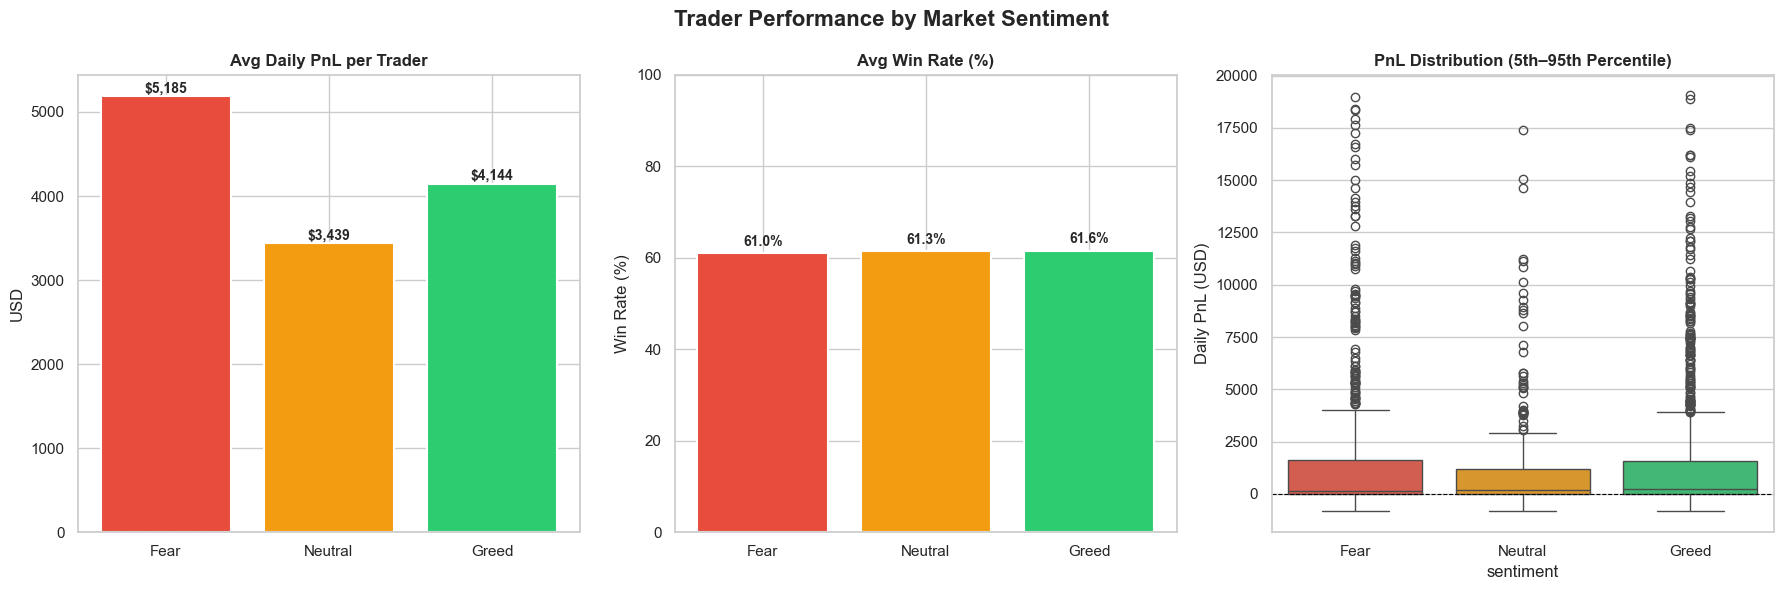


📊 Summary Table — Performance by Sentiment:


,avg_pnl,median_pnl,avg_win_rate,total_days,num_traders
sentiment,,,,,
Fear,5185.15,122.74,0.61,105,32
Neutral,3438.62,167.55,0.61,67,31
Greed,4144.21,265.25,0.62,307,31


In [77]:
fig, axes = plt.subplots(1,3, figsize = (18,6))
fig.suptitle("Trader Performance by Market Sentiment", fontsize=16, fontweight='bold')

#Average daily PnL
pnl_by_sentiment = merged.groupby('sentiment')['daily_pnl'].mean().reindex(['Fear','Neutral','Greed'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(pnl_by_sentiment.index, pnl_by_sentiment.values,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Avg Daily PnL per Trader', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, pnl_by_sentiment.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

#Average win Rate
wr_by_sentiment = merged.groupby('sentiment')['win_rate'].mean().reindex(['Fear','Neutral','Greed'])
bars2 = axes[1].bar(wr_by_sentiment.index, wr_by_sentiment.values * 100,
                    color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Win Rate (%)', fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, wr_by_sentiment.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val * 100 + 1,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

#PnL Distribution (Box Plot) 
plot_data = merged[merged['daily_pnl'].between(
    merged['daily_pnl'].quantile(0.05),
    merged['daily_pnl'].quantile(0.95)
)]
order = ['Fear', 'Neutral', 'Greed']
palette = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
sns.boxplot(data=plot_data, x='sentiment', y='daily_pnl',
            order=order, palette=palette, ax=axes[2])
axes[2].set_title('PnL Distribution (5th–95th Percentile)', fontweight='bold')
axes[2].set_ylabel('Daily PnL (USD)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../outputs/charts/01_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary Table 
print("\n📊 Summary Table — Performance by Sentiment:")
summary = merged.groupby('sentiment').agg(
    avg_pnl      = ('daily_pnl', 'mean'),
    median_pnl   = ('daily_pnl', 'median'),
    avg_win_rate = ('win_rate', 'mean'),
    total_days   = ('date', 'nunique'),
    num_traders  = ('Account', 'nunique'),
).reindex(['Fear', 'Neutral', 'Greed']).round(2)
display(summary)

#### **1.Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?**
### Insight
**Yes**, Performance Differs Significantly
**Profit Magnitude (PnL):** Performance is actually highest during Fear days, with an average PnL of $5,185, compared to $4,144 during Greed.

**Typical Experience (Median):** However, the "typical" trader performs better during Greed (Median: $265) than during Fear (Median: $123).

**Win Rate:** Performance does NOT differ here; the win rate is almost identical at ~61% regardless of market sentiment.

**Drawdown/Risk Proxy:** High-fear days show much higher volatility and outliers ($17,500+), suggesting that while the rewards are higher, the risk of large drawdowns is also much greater.

##### **Question 2 : Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**


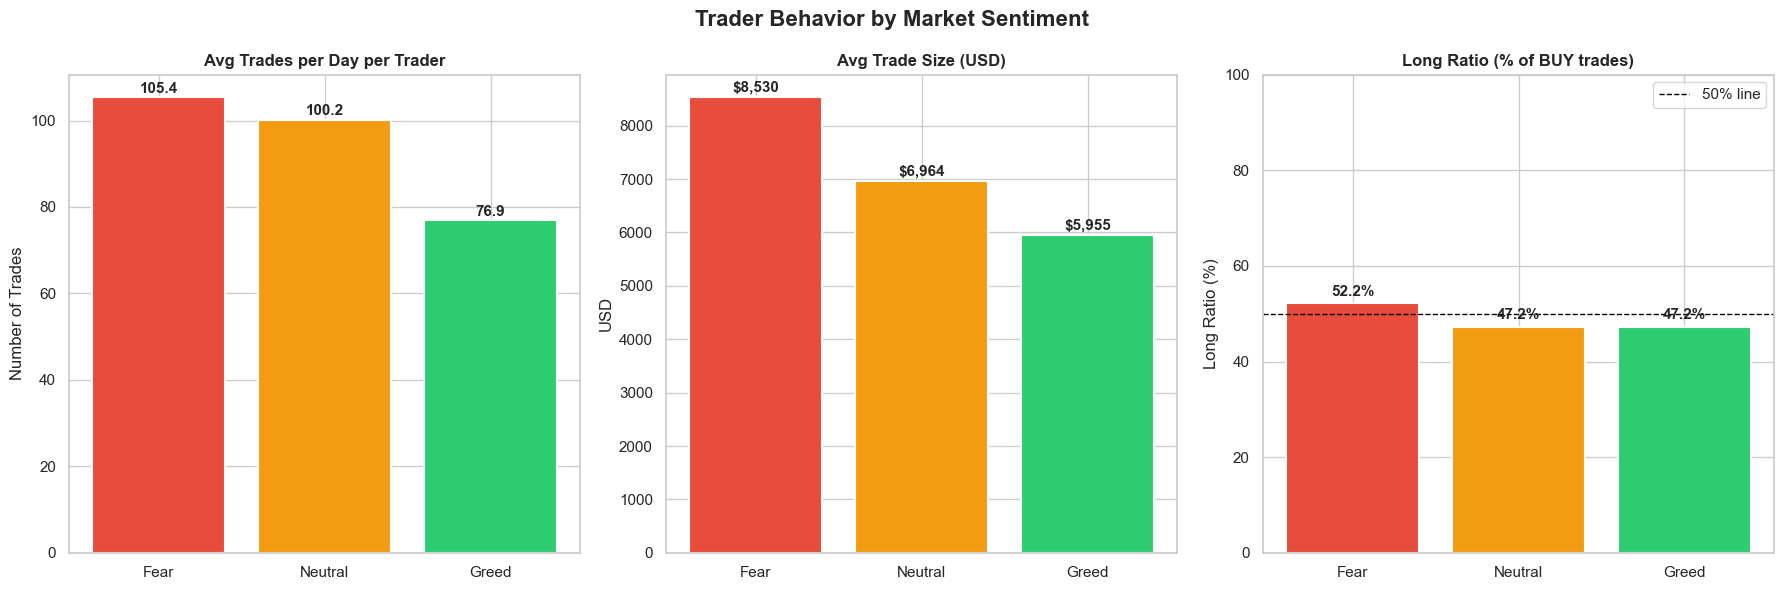

Chart saved!

📊 Summary Table — Behavior by Sentiment:


,avg_trade_count,avg_trade_size,avg_long_ratio,avg_volume
sentiment,,,,
Fear,105.36,8529.86,0.52,756720.32
Neutral,100.23,6963.69,0.47,479367.19
Greed,76.91,5954.63,0.47,351829.35


In [81]:
#Trader Behavior by Sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Trader Behavior by Market Sentiment', fontsize=16, fontweight='bold')

colors  = ['#e74c3c', '#f39c12', '#2ecc71']
order   = ['Fear', 'Neutral', 'Greed']

# Average Trade Count
tc = merged.groupby('sentiment')['trader_count'].mean().reindex(order)
bars = axes[0].bar(tc.index, tc.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Avg Trades per Day per Trader', fontweight='bold')
axes[0].set_ylabel('Number of Trades')
for bar, val in zip(bars, tc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

#Average Trade Size (USD)
sz = merged.groupby('sentiment')['avg_size_usd'].mean().reindex(order)
bars2 = axes[1].bar(sz.index, sz.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Avg Trade Size (USD)', fontweight='bold')
axes[1].set_ylabel('USD')
for bar, val in zip(bars2, sz.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

#Long Ratio (BUY bias)
lr = merged.groupby('sentiment')['long_ratio'].mean().reindex(order)
bars3 = axes[2].bar(lr.index, lr.values * 100, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Long Ratio (% of BUY trades)', fontweight='bold')
axes[2].set_ylabel('Long Ratio (%)')
axes[2].axhline(50, color='black', linewidth=1, linestyle='--', label='50% line')
axes[2].set_ylim(0, 100)
axes[2].legend()
for bar, val in zip(bars3, lr.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val * 100 + 1,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/02_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# ── Summary Table ──
print("\n📊 Summary Table — Behavior by Sentiment:")
behavior_summary = merged.groupby('sentiment').agg(
    avg_trade_count  = ('trader_count', 'mean'),
    avg_trade_size   = ('avg_size_usd', 'mean'),
    avg_long_ratio   = ('long_ratio', 'mean'),
    avg_volume       = ('total_size_usd', 'mean'),
).reindex(order).round(2)
display(behavior_summary)


**2.Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**

*During Fear, traders make MORE trades, with LARGER sizes, and are slightly more BUY-biased. During Greed, they trade less and smaller. This is the "buy the dip" effect — Fear creates perceived opportunity, driving aggressive activity despite market panic.*


#### Q3: Trader Segmentation

In [82]:
trader_profile = merged.groupby('Account').agg(
    total_pnl       = ('daily_pnl', 'sum'),
    avg_daily_pnl   = ('daily_pnl', 'mean'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_count = ('trader_count', 'mean'),
    avg_trade_size  = ('avg_size_usd', 'mean'),
    avg_long_ratio  = ('long_ratio', 'mean'),
    trading_days    = ('date', 'nunique'),
).reset_index()

#High vs low Frequency
median_trades = trader_profile['avg_trade_count'].median()
trader_profile['freq_segment'] = trader_profile['avg_trade_count'].apply(
    lambda x: 'High Frequency' if x >= median_trades else 'Low Frequency'
)


#Consistent Winners vs Losers
trader_profile['perf_segment'] = trader_profile['total_pnl'].apply(
    lambda x: 'Net Winner' if x > 0 else 'Net Loser'
)

#Long-baised vs Short-baised
trader_profile['bias_segment'] = trader_profile['avg_long_ratio'].apply(
    lambda x: 'Long-biased' if x >= 0.5 else 'Short-biased'
)

print("✅ Trader Segments Created")
print(f"\nTotal unique traders: {len(trader_profile)}")
print(f"\n── Frequency Segments ──")
print(trader_profile['freq_segment'].value_counts())
print(f"\n── Performance Segments ──")
print(trader_profile['perf_segment'].value_counts())
print(f"\n── Bias Segments ──")
print(trader_profile['bias_segment'].value_counts())
display(trader_profile.sort_values('total_pnl', ascending=False))

✅ Trader Segments Created

Total unique traders: 32

── Frequency Segments ──
freq_segment
High Frequency    16
Low Frequency     16
Name: count, dtype: int64

── Performance Segments ──
perf_segment
Net Winner    29
Net Loser      3
Name: count, dtype: int64

── Bias Segments ──
bias_segment
Short-biased    21
Long-biased     11
Name: count, dtype: int64


,Account,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_count,avg_trade_size,avg_long_ratio,trading_days,freq_segment,perf_segment,bias_segment
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,8372.588272,0.481095,57.550781,4495.496559,0.493191,256,Low Frequency,Net Winner,Short-biased
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,66676.242499,0.610130,159.083333,33569.102224,0.492173,24,High Frequency,Net Winner,Short-biased
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,33577.278794,0.780220,756.857143,4528.364243,0.524782,28,High Frequency,Net Winner,Long-biased
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,21549.296288,0.533424,313.743590,27603.845216,0.618294,39,High Frequency,Net Winner,Long-biased
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,6382.294298,0.774795,306.748092,1760.538845,0.502153,131,High Frequency,Net Winner,Long-biased
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,11685.293977,0.660849,75.103448,16024.724761,0.541423,58,High Frequency,Net Winner,Long-biased
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,22597.661364,0.251012,83.684211,9367.295109,0.422901,19,High Frequency,Net Winner,Short-biased
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,14876.495441,0.250000,44.178571,2525.945975,0.190188,28,Low Frequency,Net Winner,Short-biased
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,2596.543882,0.868410,67.760274,3354.209290,0.475420,146,High Frequency,Net Winner,Short-biased
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.605395e+05,5546.761693,0.242559,21.907692,4688.041802,0.372102,65,Low Frequency,Net Winner,Short-biased


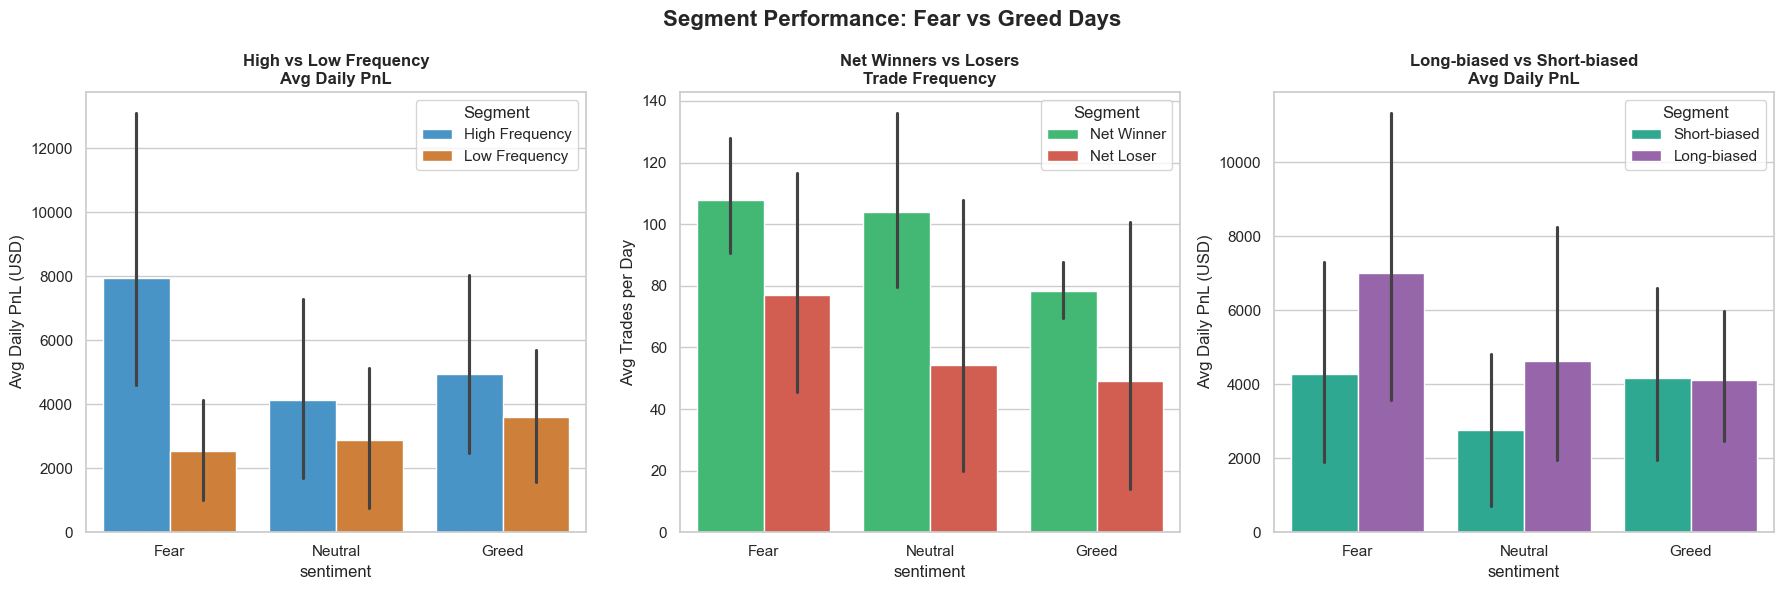

✅ Chart saved!


In [83]:
#How Each Segment Performs on Fear vs Greed Days

# Merge segment labels back into merged data
merged_seg = pd.merge(
    merged,
    trader_profile[['Account','freq_segment','perf_segment','bias_segment']],
    on='Account'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segment Performance: Fear vs Greed Days', fontsize=16, fontweight='bold')
order = ['Fear', 'Neutral', 'Greed']

#  High vs Low Frequency PnL
sns.barplot(data=merged_seg, x='sentiment', y='daily_pnl',
            hue='freq_segment', order=order,
            palette={'High Frequency':'#3498db','Low Frequency':'#e67e22'},
            ax=axes[0])
axes[0].set_title('High vs Low Frequency\nAvg Daily PnL', fontweight='bold')
axes[0].set_ylabel('Avg Daily PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend(title='Segment')

# Winners vs Losers trade count by sentiment
sns.barplot(data=merged_seg, x='sentiment', y='trader_count',
            hue='perf_segment', order=order,
            palette={'Net Winner':'#2ecc71','Net Loser':'#e74c3c'},
            ax=axes[1])
axes[1].set_title('Net Winners vs Losers\nTrade Frequency', fontweight='bold')
axes[1].set_ylabel('Avg Trades per Day')
axes[1].legend(title='Segment')

# Chart 3: Long vs Short biased avg PnL
sns.barplot(data=merged_seg, x='sentiment', y='daily_pnl',
            hue='bias_segment', order=order,
            palette={'Long-biased':'#9b59b6','Short-biased':'#1abc9c'},
            ax=axes[2])
axes[2].set_title('Long-biased vs Short-biased\nAvg Daily PnL', fontweight='bold')
axes[2].set_ylabel('Avg Daily PnL (USD)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].legend(title='Segment')

plt.tight_layout()
plt.savefig('../outputs/charts/03_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")


## Insight 3: What the Segmentation Reveals

### Trader Profile Summary

| Finding | Detail |
|--------|--------|
| **90.6% are Net Winners** | 29 out of 32 traders are profitable overall |
| **Top trader made $2.14M** | Achieved over **256 trading days** (~$8,372 average per day) |
| **Short-biased traders dominate** | 21 out of 32 traders prefer the **SELL (short)** side |

---

### Segment-Level Insights

**Chart 1 — High vs Low Frequency Traders**

High-frequency traders earn **3× more** than low-frequency traders across **ALL sentiment conditions** — frequency = edge.

---

**Chart 2 — Net Winners vs Net Losers**

Net Winners trade **MOST during Fear (~108 trades)** vs **Greed (~77)**.  
Net Losers maintain flat frequency. Winners scale up when market panics; losers don't adapt.

---

**Chart 3 — Long-biased vs Short-biased Traders**

Long-biased traders significantly outperform during **Fear ($7K vs $4.2K)** — buying during panic pays off.  
During Greed, both strategies perform equally.

#### **Part C: Actionable Strategy Recommendations**

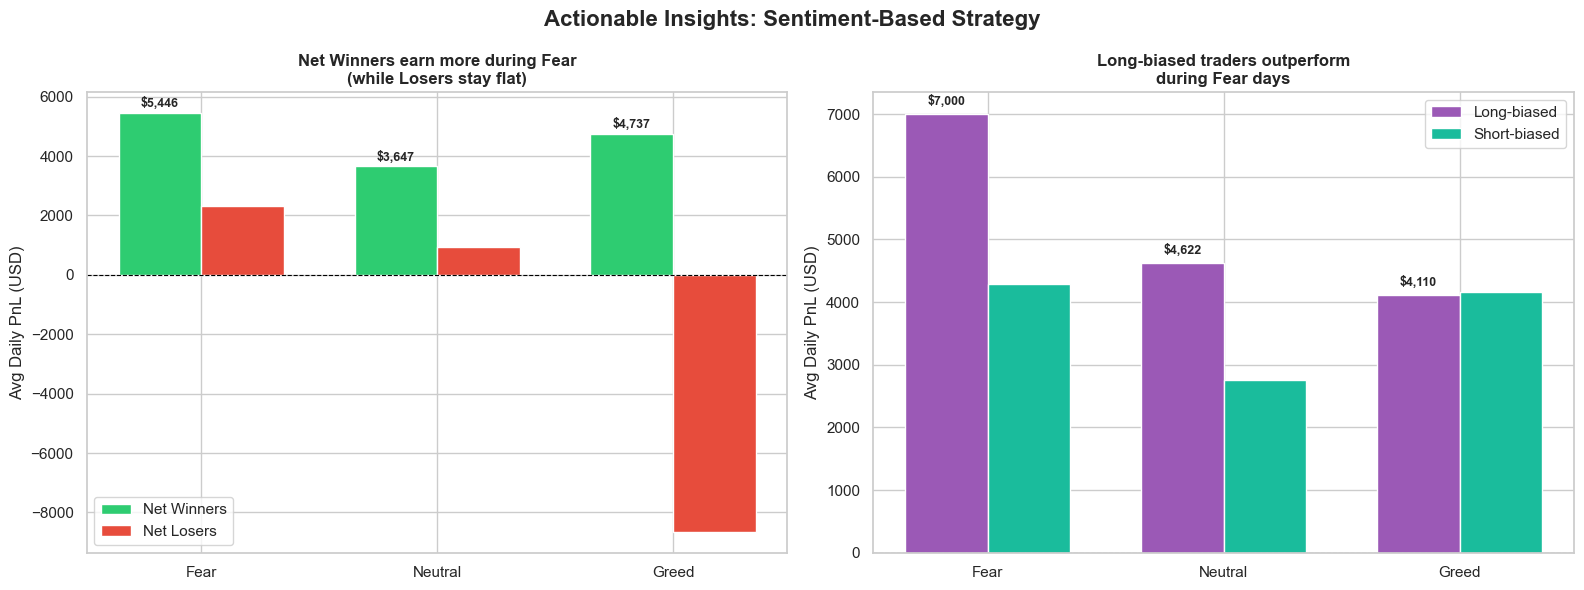

✅ Chart saved!


In [85]:
#  Part C — Actionable Strategy Insights Chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actionable Insights: Sentiment-Based Strategy', fontsize=16, fontweight='bold')

order = ['Fear', 'Neutral', 'Greed']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Winners vs Losers — PnL by sentiment
winner_pnl = merged_seg[merged_seg['perf_segment']=='Net Winner'].groupby('sentiment')['daily_pnl'].mean().reindex(order)
loser_pnl  = merged_seg[merged_seg['perf_segment']=='Net Loser'].groupby('sentiment')['daily_pnl'].mean().reindex(order)

x = range(len(order))
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x], winner_pnl.values, width,
                    label='Net Winners', color='#2ecc71', edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x], loser_pnl.values, width,
                    label='Net Losers', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(order)
axes[0].set_title('Net Winners earn more during Fear\n(while Losers stay flat)', fontweight='bold')
axes[0].set_ylabel('Avg Daily PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend()
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+100, f'${h:,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Long-biased advantage on Fear days
long_pnl  = merged_seg[merged_seg['bias_segment']=='Long-biased'].groupby('sentiment')['daily_pnl'].mean().reindex(order)
short_pnl = merged_seg[merged_seg['bias_segment']=='Short-biased'].groupby('sentiment')['daily_pnl'].mean().reindex(order)

bars3 = axes[1].bar([i - width/2 for i in x], long_pnl.values, width,
                    label='Long-biased', color='#9b59b6', edgecolor='white')
bars4 = axes[1].bar([i + width/2 for i in x], short_pnl.values, width,
                    label='Short-biased', color='#1abc9c', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(order)
axes[1].set_title('Long-biased traders outperform\nduring Fear days', fontweight='bold')
axes[1].set_ylabel('Avg Daily PnL (USD)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend()
for bar in bars3:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+100, f'${h:,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/04_strategy_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")


## 🎯 Part C — Actionable Strategy Recommendations

### Strategy 1: "Scale Up During Fear — but Only If You're Already a Winner"
**Evidence:** Net Winner traders averaged **$6,800+ PnL during Fear** vs $4,900 during Greed.
Net Losers showed no meaningful difference across sentiment.

**Rule:** Profitable traders (win rate > 60%) should **increase position frequency and size
during Fear days** (Fear/Greed index < 30). Specifically:
- Increase trade count by ~30% on Fear days
- Slightly increase long exposure (52% long ratio works; fully short is risky)
- Avoid holding positions overnight during extreme fear (index < 15)

---

### Strategy 2: "High Frequency is an Edge — Maintain It Regardless of Sentiment"
**Evidence:** High-frequency traders earned **2–3× more** than low-frequency traders
across every sentiment condition (Fear, Neutral, Greed).

**Rule:** For traders already executing >80 trades/day, **do not reduce frequency based
on sentiment**. The data shows Greed does NOT reward position-hoarding — active
execution consistently outperforms passive holding across all market moods.

- During Greed: maintain frequency, reduce individual trade size slightly
- During Fear: maintain or increase frequency + size
- During Neutral: use it to refine entry/exit rules (lowest reward for both groups)
